In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis)
from sklearn import datasets

from scipy import linalg

import statsmodels.api as sm

Logistic regression of the credit card default dataset, using "balance" as the predictor.

In [2]:
df = pd.read_csv('Default.csv')
df["default"] = df["default"].map({"Yes":1.0, "No":0.0})
display(df)

X = sm.add_constant(df[["balance"]])

display(X)
Y = df[["default"]]

logicRegr = sm.Logit(Y,X).fit()
print(logicRegr.summary())

,default,student,balance,income
0,0.0,No,729.526495,44361.625074
1,0.0,Yes,817.180407,12106.134700
2,0.0,No,1073.549164,31767.138947
3,0.0,No,529.250605,35704.493935
4,0.0,No,785.655883,38463.495879
...,...,...,...,...
9995,0.0,No,711.555020,52992.378914
9996,0.0,No,757.962918,19660.721768
9997,0.0,No,845.411989,58636.156984
9998,0.0,No,1569.009053,36669.112365


,const,balance
0,1.0,729.526495
1,1.0,817.180407
2,1.0,1073.549164
3,1.0,529.250605
4,1.0,785.655883
...,...,...
9995,1.0,711.555020
9996,1.0,757.962918
9997,1.0,845.411989
9998,1.0,1569.009053


Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Oct 2025   Pseudo R-squ.:                  0.4534
Time:                        01:14:37   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6513      0.361    -29.491      0.000     -11.359      -9.943
balance        0.0055      0

Predicting default status based on the "student" variable

In [3]:
X = sm.add_constant(pd.get_dummies(df["student"], prefix="Student", prefix_sep="_", drop_first=True))

display(X)

logicRegr = sm.Logit(Y,X.astype(float)).fit()
print(logicRegr.summary())

,const,Student_Yes
0,1.0,False
1,1.0,True
2,1.0,False
3,1.0,False
4,1.0,False
...,...,...
9995,1.0,False
9996,1.0,False
9997,1.0,False
9998,1.0,False


Optimization terminated successfully.
         Current function value: 0.145434
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Oct 2025   Pseudo R-squ.:                0.004097
Time:                        01:14:37   Log-Likelihood:                -1454.3
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                 0.0005416
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.5041      0.071    -49.554      0.000      -3.643      -3.366
Student_Yes     0.4049    

Logistic regression with several variables, including balance, income and student

In [4]:
X = df[["balance", "income", "student"]]
X = pd.get_dummies(X, columns=["student"], prefix="Student", prefix_sep="_", drop_first=True)
X = sm.add_constant(X)

display(X)

logicRegr = sm.Logit(Y,X.astype(float)).fit()
print(logicRegr.summary())

,const,balance,income,Student_Yes
0,1.0,729.526495,44361.625074,False
1,1.0,817.180407,12106.134700,True
2,1.0,1073.549164,31767.138947,False
3,1.0,529.250605,35704.493935,False
4,1.0,785.655883,38463.495879,False
...,...,...,...,...
9995,1.0,711.555020,52992.378914,False
9996,1.0,757.962918,19660.721768,False
9997,1.0,845.411989,58636.156984,False
9998,1.0,1569.009053,36669.112365,False


Optimization terminated successfully.
         Current function value: 0.078577
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Tue, 07 Oct 2025   Pseudo R-squ.:                  0.4619
Time:                        01:14:37   Log-Likelihood:                -785.77
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                3.257e-292
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -10.8690      0.492    -22.079      0.000     -11.834      -9.904
balance         0.0057   

South African Heart Disease

In [5]:
df2 =  pd.read_csv('SouthAfricanHeartDisease_withheader.csv')
df2['CLASS'] = df2['CLASS'].replace(-1, 0)
display(df2)

X = df2[["sbp", "tobacco", "ldl", "famhist", "obesity", "alcohol", "age"]]
# X = pd.get_dummies(X, columns=["famhist"], prefix="has_familyHistory", prefix_sep="_", drop_first=True)
X = sm.add_constant(X)

Y = df2[["CLASS"]]

logicRegr = sm.Logit(Y,X).fit()
print(logicRegr.summary())

,CLASS,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age
0,1,160,12.00,5.73,23.11,1,49,25.30,97.20,52
1,1,144,0.01,4.41,28.61,0,55,28.87,2.06,63
2,0,118,0.08,3.48,32.28,1,52,29.14,3.81,46
3,1,170,7.50,6.41,38.03,1,51,31.99,24.26,58
4,1,134,13.60,3.50,27.78,1,60,25.99,57.34,49
...,...,...,...,...,...,...,...,...,...,...
457,0,214,0.40,5.98,31.72,0,64,28.45,0.00,58
458,1,182,4.20,4.41,32.10,0,52,28.61,18.72,52
459,0,108,3.00,1.59,15.23,0,40,20.09,26.64,55
460,0,118,5.40,11.61,30.79,0,64,27.35,23.97,40


Optimization terminated successfully.
         Current function value: 0.522916
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  CLASS   No. Observations:                  462
Model:                          Logit   Df Residuals:                      454
Method:                           MLE   Df Model:                            7
Date:                Tue, 07 Oct 2025   Pseudo R-squ.:                  0.1895
Time:                        01:14:38   Log-Likelihood:                -241.59
converged:                       True   LL-Null:                       -298.05
Covariance Type:            nonrobust   LLR p-value:                 2.259e-21
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.1296      0.964     -4.283      0.000      -6.019      -2.240
sbp            0.0058      0.

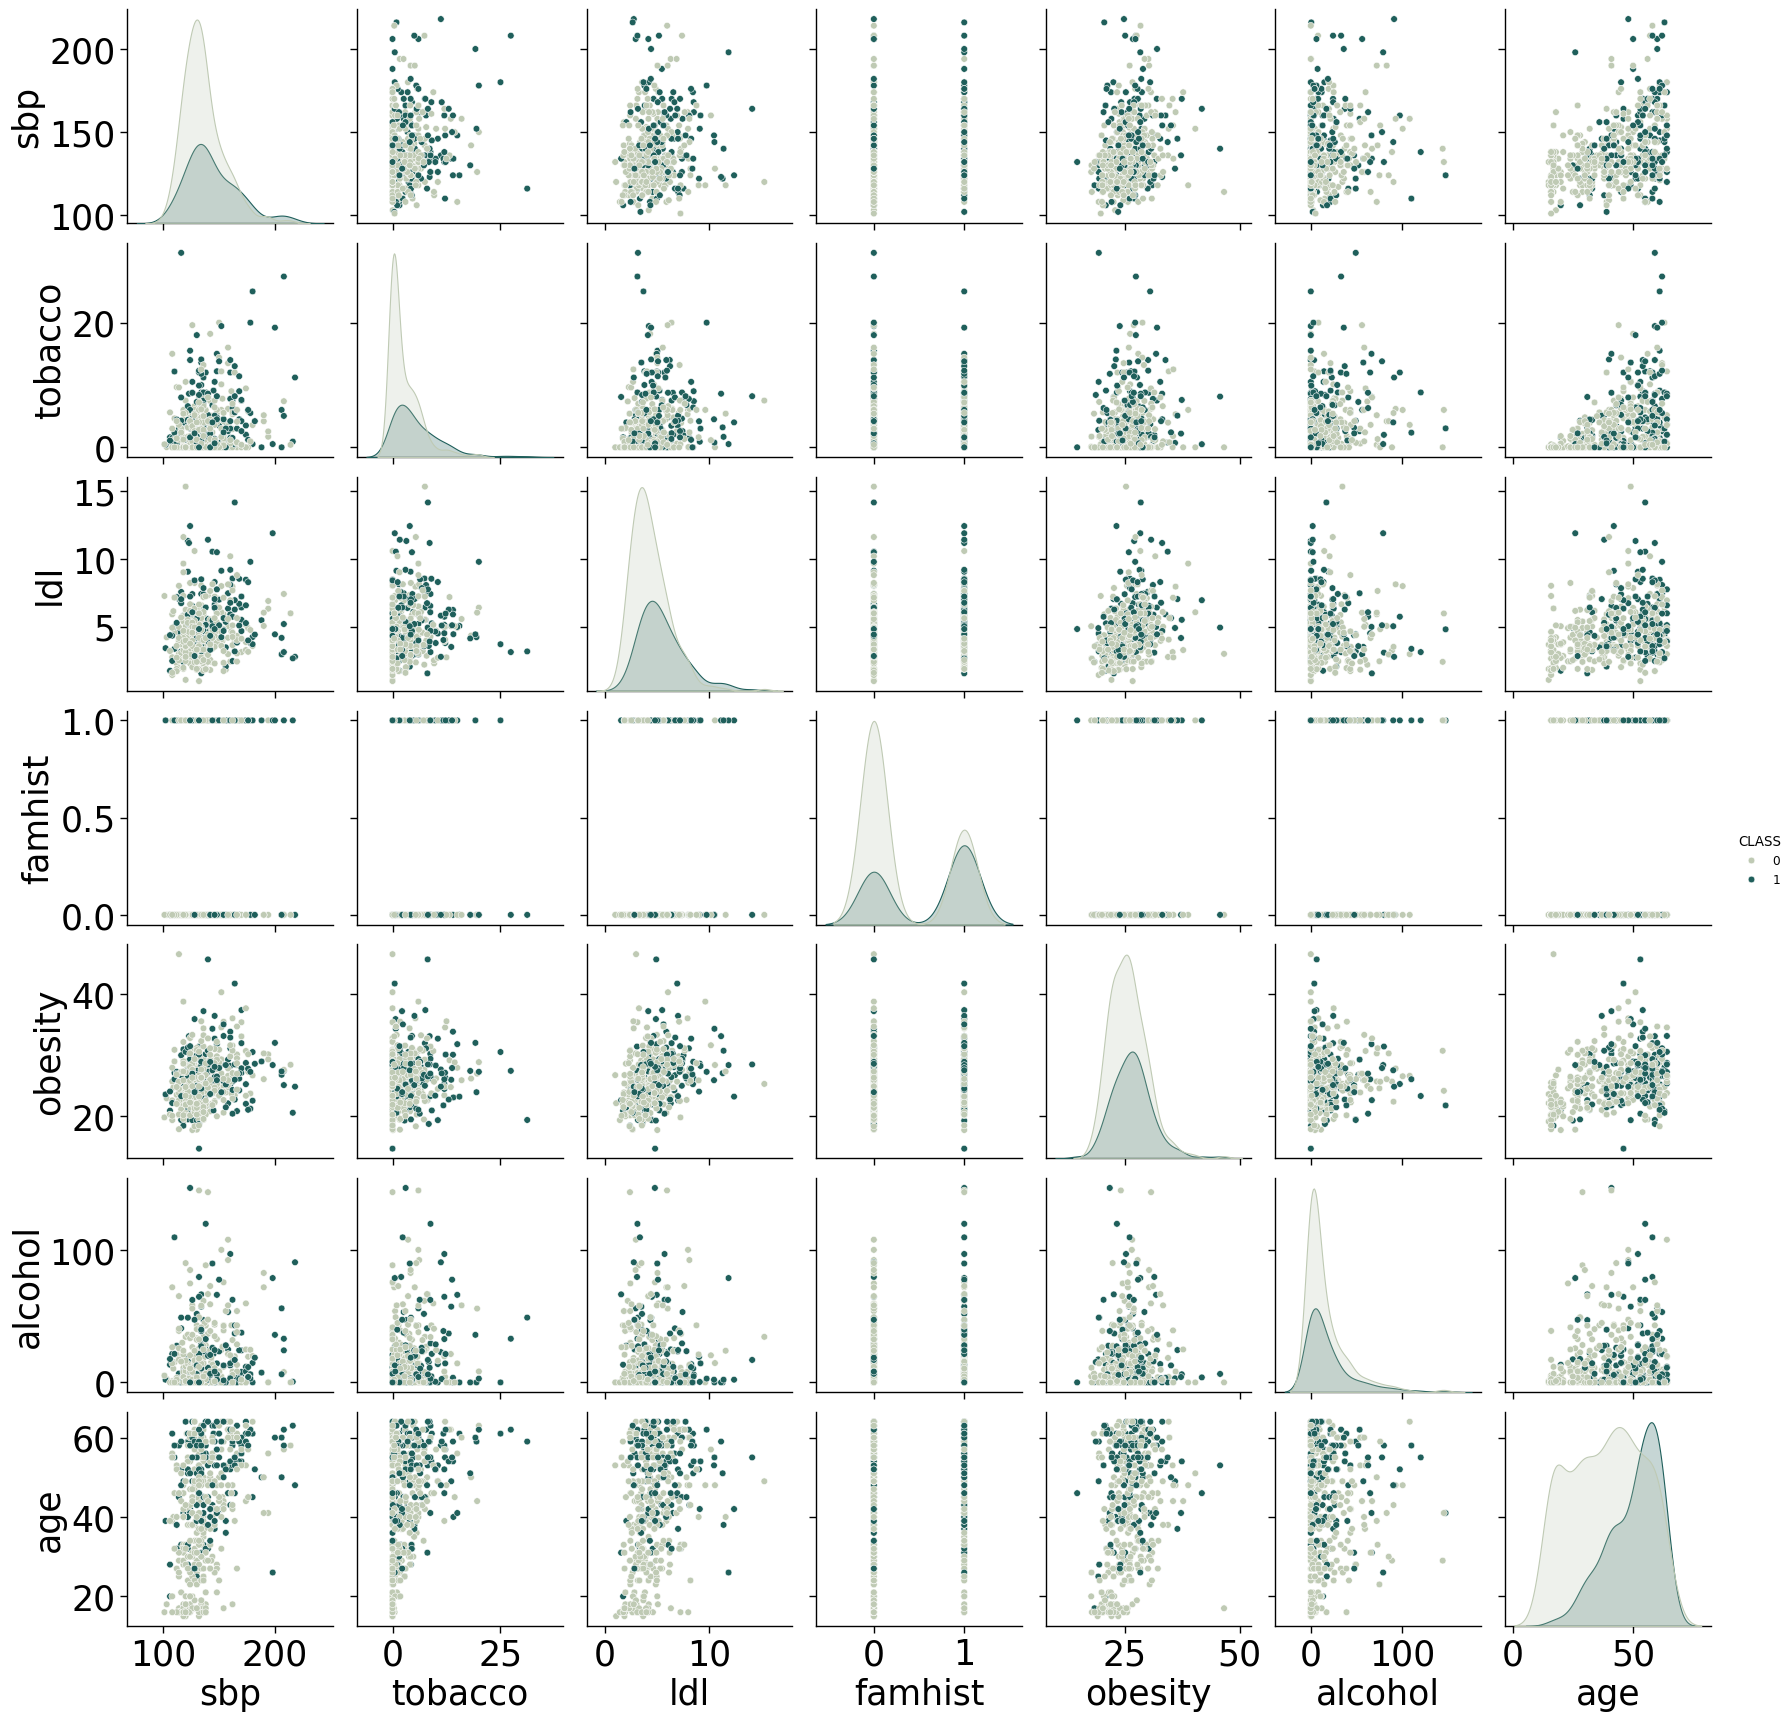

In [6]:
sns.set_context("paper", rc={"axes.labelsize":25, "xtick.labelsize":25, "ytick.labelsize":25})

sns.pairplot(df2[["CLASS", "sbp", "tobacco", "ldl", "famhist", "obesity", "alcohol", "age"]], hue="CLASS", palette={0:"#BFCAB4", 1:"#1F5F5B"}, diag_kind="auto")